In [1]:
%load_ext autoreload
%autoreload 2
%matplotlib inline

In [2]:
import os
import yaml
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib.collections import LineCollection
from tueplots import bundles

from bridgeop.utils.trainer import TrainerModule, ScoreModel
from bridgeop.utils.data import DataFactory
from bridgeop.diffusion.sde import SDEFactory

2024-10-17 15:44:28.599522: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:485] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2024-10-17 15:44:28.615916: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:8454] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2024-10-17 15:44:28.620633: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1452] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2024-10-17 15:44:30.080236: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT Warning: Could not find TensorRT


In [3]:
plt.rcParams.update(
    bundles.icml2022(column="full", nrows=2, ncols=2, usetex=False, family="sans-serif")
)

### Ellipse

In [4]:
def eval_error(trainer, config, n_eval_pts, n_samples):
    data_config = config.get("data", {})
    data = DataFactory.create(data_config)
    data_evals = data.eval(n_eval_pts)
    x0 = data_evals["x0"]
    v  = data_evals["v"]
    print(f"x0: {x0.shape}, v: {v.shape}")
    
    def true_drift(t, x):
        return (x0 - x) / (t + 1e-8)

    score_model = ScoreModel(x0, trainer)
    db_config = config["diffusion_bridge"]
    db_config["sde_kwargs"]["W_shape"] = [n_eval_pts[0], 2]
    trainer.update_db(db_config)
    reverse_path = trainer.db.solve_reverse_bridge(
        rng_key=jax.random.PRNGKey(config["training"]["seed"]),
        xT=v,
        model=score_model,
        n_batches=n_samples,
        return_drift=True
    )
    est_drifts = reverse_path.fs.reshape((n_samples, -1, *n_eval_pts, 2))
    true_drifts = jax.vmap(
        jax.vmap(
            true_drift,
            in_axes=(0, 0),
            out_axes=0
        ),
        in_axes=(None, 0),
        out_axes=0
        )(reverse_path.ts, reverse_path.xs)
    drift_error = jnp.linalg.norm(est_drifts - true_drifts, axis=-1)
    
    end_shape = reverse_path.xs[:, -1, ...]
    end_shape_error = jnp.linalg.norm(end_shape - v[None, ...], axis=-1)
    return jnp.mean(drift_error), jnp.mean(end_shape_error)

In [28]:
n_train_pts = (8, 16, 32, 48, 64)
n_eval_pts = range(16, 256, 16)
all_drift_errors = []
all_end_shape_errors = []
for n_train_pt in n_train_pts:
    drift_errors = []
    end_shape_errors = []
    ckpt_path = f"../ckpts/ellipse_brownian_{n_train_pt:02}train_npts"
    config_path = "../src/config.yaml"
    with open(config_path, "r") as f:
        config = yaml.safe_load(f)
    config = config["ellipse_brownian"]
        
    cwd = os.getcwd()
    ckpt_path = os.path.join(cwd, ckpt_path)
    ckpt_path = os.path.normpath(ckpt_path)
    config["training"]["dir"] = ckpt_path
    
    trainer = TrainerModule(config)
    trainer.train_model(x0=None, mode="pretrained", step=None)
    for n_eval_pt in n_eval_pts:
        drift_error, end_shape_error = eval_error(trainer, config, n_eval_pts=(n_eval_pt, ), n_samples=64)
        drift_errors.append(drift_error)
        end_shape_errors.append(end_shape_error)
    all_drift_errors.append(drift_errors)
    all_end_shape_errors.append(end_shape_errors)

/home/gefan/miniconda3/envs/bridgeop/lib/python3.12/site-packages/orbax/checkpoint/type_handlers.py:1330: UserWarning: Couldn't find sharding info under RestoreArgs. Populating sharding info from sharding file. Please note restoration time will be slightly increased due to reading from file instead of directly from RestoreArgs. Note also that this option is unsafe when restoring on a different topology than the checkpoint was saved with.
  warnings.warn(


Model loaded from /home/gefan/projects/scoreoperator/ckpts/ellipse_brownian_08train_npts/checkpoint__step_10000
x0: (16, 2), v: (16, 2)
x0: (32, 2), v: (32, 2)
x0: (48, 2), v: (48, 2)
x0: (64, 2), v: (64, 2)
x0: (80, 2), v: (80, 2)
x0: (96, 2), v: (96, 2)
x0: (112, 2), v: (112, 2)
x0: (128, 2), v: (128, 2)
x0: (144, 2), v: (144, 2)
x0: (160, 2), v: (160, 2)
x0: (176, 2), v: (176, 2)
x0: (192, 2), v: (192, 2)
x0: (208, 2), v: (208, 2)
x0: (224, 2), v: (224, 2)
x0: (240, 2), v: (240, 2)


/home/gefan/miniconda3/envs/bridgeop/lib/python3.12/site-packages/orbax/checkpoint/type_handlers.py:1330: UserWarning: Couldn't find sharding info under RestoreArgs. Populating sharding info from sharding file. Please note restoration time will be slightly increased due to reading from file instead of directly from RestoreArgs. Note also that this option is unsafe when restoring on a different topology than the checkpoint was saved with.
  warnings.warn(


Model loaded from /home/gefan/projects/scoreoperator/ckpts/ellipse_brownian_16train_npts/checkpoint__step_10000
x0: (16, 2), v: (16, 2)
x0: (32, 2), v: (32, 2)
x0: (48, 2), v: (48, 2)
x0: (64, 2), v: (64, 2)
x0: (80, 2), v: (80, 2)
x0: (96, 2), v: (96, 2)
x0: (112, 2), v: (112, 2)
x0: (128, 2), v: (128, 2)
x0: (144, 2), v: (144, 2)
x0: (160, 2), v: (160, 2)
x0: (176, 2), v: (176, 2)
x0: (192, 2), v: (192, 2)
x0: (208, 2), v: (208, 2)
x0: (224, 2), v: (224, 2)
x0: (240, 2), v: (240, 2)


/home/gefan/miniconda3/envs/bridgeop/lib/python3.12/site-packages/orbax/checkpoint/type_handlers.py:1330: UserWarning: Couldn't find sharding info under RestoreArgs. Populating sharding info from sharding file. Please note restoration time will be slightly increased due to reading from file instead of directly from RestoreArgs. Note also that this option is unsafe when restoring on a different topology than the checkpoint was saved with.
  warnings.warn(


Model loaded from /home/gefan/projects/scoreoperator/ckpts/ellipse_brownian_32train_npts/checkpoint__step_10000
x0: (16, 2), v: (16, 2)
x0: (32, 2), v: (32, 2)
x0: (48, 2), v: (48, 2)
x0: (64, 2), v: (64, 2)
x0: (80, 2), v: (80, 2)
x0: (96, 2), v: (96, 2)
x0: (112, 2), v: (112, 2)
x0: (128, 2), v: (128, 2)
x0: (144, 2), v: (144, 2)
x0: (160, 2), v: (160, 2)
x0: (176, 2), v: (176, 2)
x0: (192, 2), v: (192, 2)
x0: (208, 2), v: (208, 2)
x0: (224, 2), v: (224, 2)
x0: (240, 2), v: (240, 2)


/home/gefan/miniconda3/envs/bridgeop/lib/python3.12/site-packages/orbax/checkpoint/type_handlers.py:1330: UserWarning: Couldn't find sharding info under RestoreArgs. Populating sharding info from sharding file. Please note restoration time will be slightly increased due to reading from file instead of directly from RestoreArgs. Note also that this option is unsafe when restoring on a different topology than the checkpoint was saved with.
  warnings.warn(


Model loaded from /home/gefan/projects/scoreoperator/ckpts/ellipse_brownian_48train_npts/checkpoint__step_10000
x0: (16, 2), v: (16, 2)
x0: (32, 2), v: (32, 2)
x0: (48, 2), v: (48, 2)
x0: (64, 2), v: (64, 2)
x0: (80, 2), v: (80, 2)
x0: (96, 2), v: (96, 2)
x0: (112, 2), v: (112, 2)
x0: (128, 2), v: (128, 2)
x0: (144, 2), v: (144, 2)
x0: (160, 2), v: (160, 2)
x0: (176, 2), v: (176, 2)
x0: (192, 2), v: (192, 2)
x0: (208, 2), v: (208, 2)
x0: (224, 2), v: (224, 2)
x0: (240, 2), v: (240, 2)


/home/gefan/miniconda3/envs/bridgeop/lib/python3.12/site-packages/orbax/checkpoint/type_handlers.py:1330: UserWarning: Couldn't find sharding info under RestoreArgs. Populating sharding info from sharding file. Please note restoration time will be slightly increased due to reading from file instead of directly from RestoreArgs. Note also that this option is unsafe when restoring on a different topology than the checkpoint was saved with.
  warnings.warn(


Model loaded from /home/gefan/projects/scoreoperator/ckpts/ellipse_brownian_64train_npts/checkpoint__step_10000
x0: (16, 2), v: (16, 2)
x0: (32, 2), v: (32, 2)
x0: (48, 2), v: (48, 2)
x0: (64, 2), v: (64, 2)
x0: (80, 2), v: (80, 2)
x0: (96, 2), v: (96, 2)
x0: (112, 2), v: (112, 2)
x0: (128, 2), v: (128, 2)
x0: (144, 2), v: (144, 2)
x0: (160, 2), v: (160, 2)
x0: (176, 2), v: (176, 2)
x0: (192, 2), v: (192, 2)
x0: (208, 2), v: (208, 2)
x0: (224, 2), v: (224, 2)
x0: (240, 2), v: (240, 2)


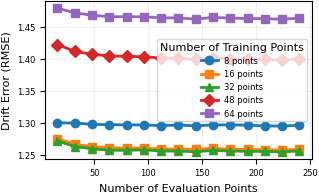

In [31]:
with plt.rc_context(bundles.icml2022(column="half", nrows=1, ncols=1, usetex=False, family="sans-serif")):  
    plt.figure()
    plt.plot(n_eval_pts, all_drift_errors[0], label="8 points", marker='o', linestyle='-', linewidth=2)
    plt.plot(n_eval_pts, all_drift_errors[1], label="16 points", marker='s', linestyle='-', linewidth=2)
    plt.plot(n_eval_pts, all_drift_errors[2], label="32 points", marker='^', linestyle='-', linewidth=2)
    plt.plot(n_eval_pts, all_drift_errors[3], label="48 points", marker='D', linestyle='-', linewidth=2)
    plt.plot(n_eval_pts, all_drift_errors[4], label="64 points", marker='s', linestyle='-', linewidth=2)

    plt.xlabel('Number of Evaluation Points')
    plt.ylabel('Drift Error (RMSE)')
    plt.grid(True, which="both", ls="-", alpha=0.2)

    plt.legend(loc='best', title="Number of Training Points")
    # plt.tight_layout()

    plt.savefig('dis_drift_error_vs_eval_points.pdf', dpi=300, bbox_inches='tight')
    plt.show()


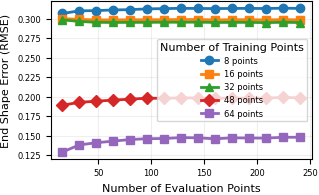

In [32]:
with plt.rc_context(bundles.icml2022(column="half", nrows=1, ncols=1, usetex=False, family="sans-serif")):  
    plt.figure()
    plt.plot(n_eval_pts, all_end_shape_errors[0], label="8 points", marker='o', linestyle='-', linewidth=2)
    plt.plot(n_eval_pts, all_end_shape_errors[1], label="16 points", marker='s', linestyle='-', linewidth=2)
    plt.plot(n_eval_pts, all_end_shape_errors[2], label="32 points", marker='^', linestyle='-', linewidth=2)
    plt.plot(n_eval_pts, all_end_shape_errors[3], label="48 points", marker='D', linestyle='-', linewidth=2)
    plt.plot(n_eval_pts, all_end_shape_errors[4], label="64 points", marker='s', linestyle='-', linewidth=2)

    plt.xlabel('Number of Evaluation Points')
    plt.ylabel('End Shape Error (RMSE)')
    plt.grid(True, which="both", ls="-", alpha=0.2)

    plt.legend(loc='best', title="Number of Training Points")
    # plt.tight_layout()

    plt.savefig('dis_end_shape_error_vs_eval_points.pdf', dpi=300, bbox_inches='tight')
    plt.show()

Number of trainable parameters: 294,130
Model loaded from /home/gefan/projects/scoreoperator/ckpts/ellipse_brownian_32train_npts/checkpoint__step_10000


/home/gefan/miniconda3/envs/bridgeop/lib/python3.12/site-packages/orbax/checkpoint/type_handlers.py:1330: UserWarning: Couldn't find sharding info under RestoreArgs. Populating sharding info from sharding file. Please note restoration time will be slightly increased due to reading from file instead of directly from RestoreArgs. Note also that this option is unsafe when restoring on a different topology than the checkpoint was saved with.
  warnings.warn(


x0: (16, 2), v: (16, 2)
x0: (32, 2), v: (32, 2)
x0: (64, 2), v: (64, 2)
x0: (128, 2), v: (128, 2)


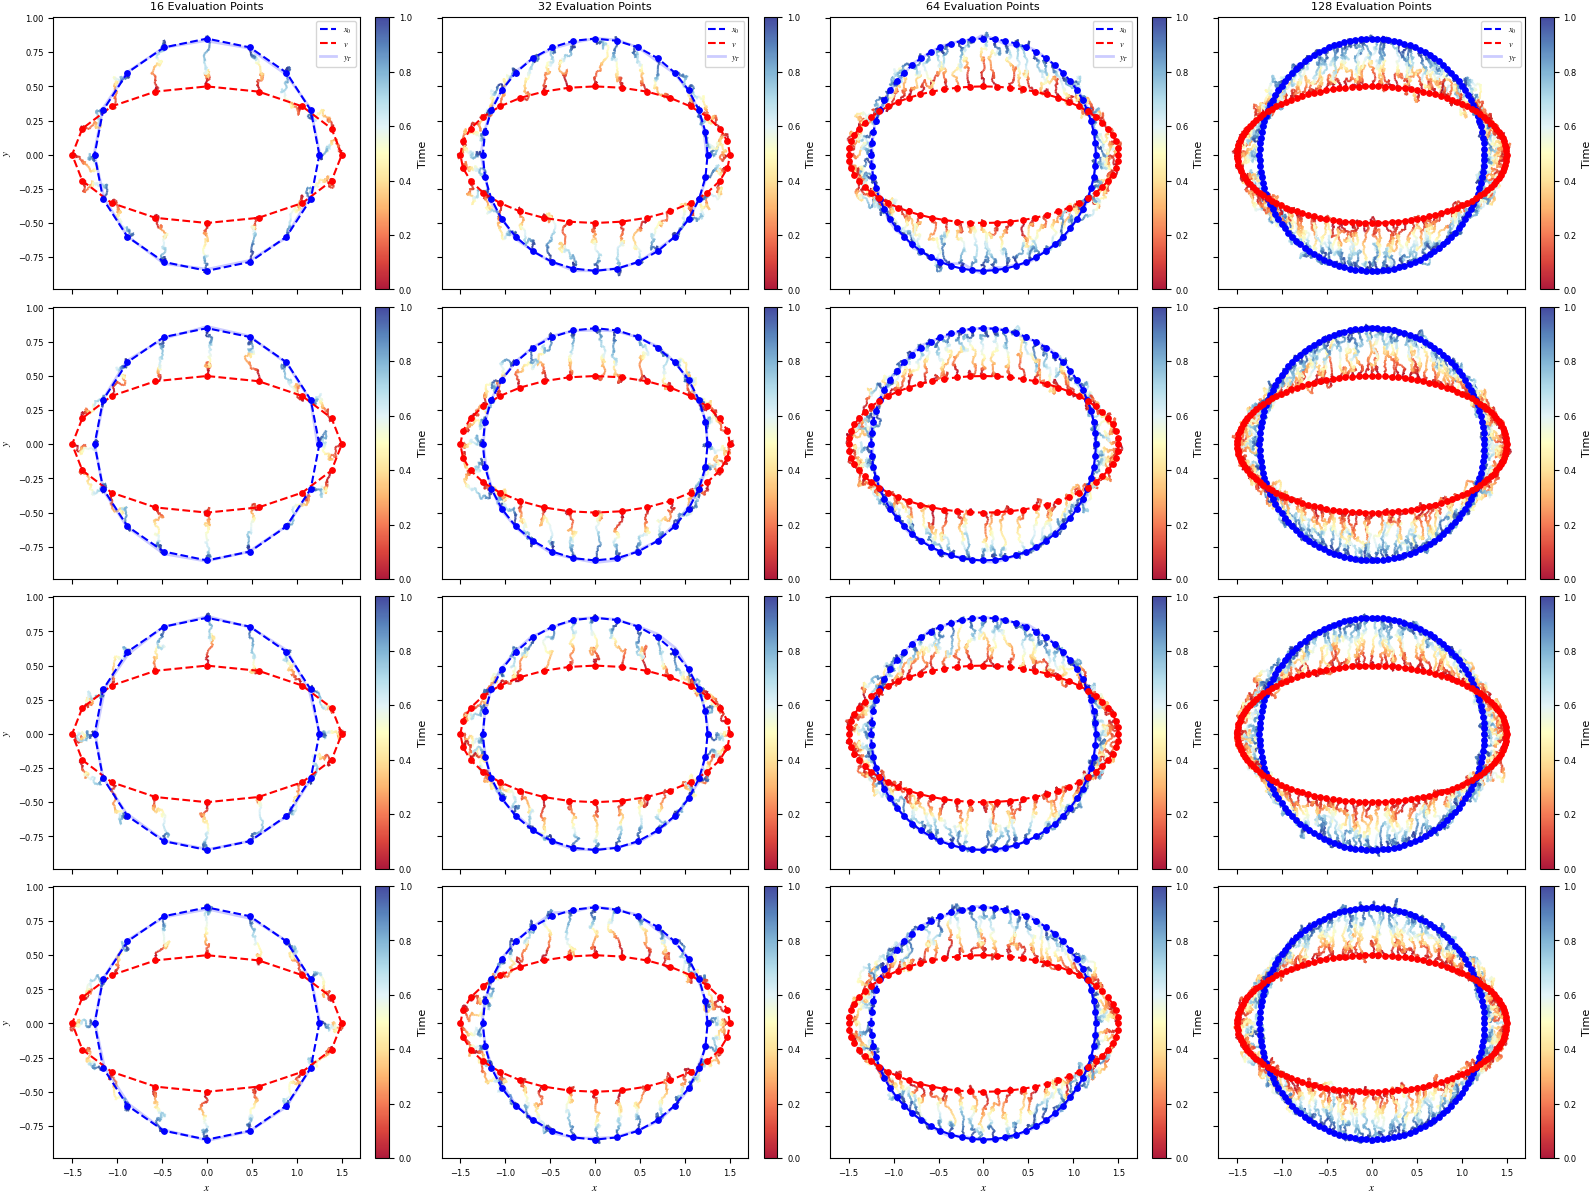

In [10]:
ckpt_path = f"../ckpts/ellipse_brownian_{32:02}train_npts"
config_path = "../src/config.yaml"
with open(config_path, "r") as f:
    config = yaml.safe_load(f)
config = config["ellipse_brownian"]
    
cwd = os.getcwd()
ckpt_path = os.path.join(cwd, ckpt_path)
ckpt_path = os.path.normpath(ckpt_path)
config["training"]["dir"] = ckpt_path

trainer = TrainerModule(config)
trainer.train_model(x0=None, mode="pretrained", step=None)
data_config = config.get("data", {})
data = DataFactory.create(data_config)

def solve_reverse_bridge(n_eval_pts):
    data_evals = data.eval((n_eval_pts, ))
    x0 = data_evals["x0"]
    v  = data_evals["v"]
    print(f"x0: {x0.shape}, v: {v.shape}")

    # score_model = ScoreModel(x0, trainer)
    score_model = lambda t, x: (x0.flatten() - x) / (t + 1e-8)
    db_config = config["diffusion_bridge"]
    db_config["sde_kwargs"]["W_shape"] = [n_eval_pts, 2]
    trainer.update_db(db_config)
    reverse_path = trainer.db.solve_reverse_bridge(
        rng_key=jax.random.PRNGKey(config["training"]["seed"]),
        xT=v,
        model=score_model,
        n_batches=4,
    )
    return x0, v, reverse_path

with plt.rc_context(bundles.icml2022(column="full", nrows=4, ncols=4, usetex=False, family="sans-serif")):  
    fig, axs = plt.subplots(4, 4, sharex=True, sharey=True, figsize=(16, 12))
    for i, n_eval_pts in enumerate([16, 32, 64, 128]):
        x0, v, reverse_path = solve_reverse_bridge(n_eval_pts)
        
        for j in range(4):
            axs[j, i].scatter(x0[:, 0], x0[:, 1], color="blue", zorder=3, s=15)
            # Connect x0 to form a closed curve
            x0_closed = jnp.vstack((x0, x0[0]))  # Add the first point to the end to close the curve
            axs[j, i].plot(x0_closed[:, 0], x0_closed[:, 1], color="blue", linestyle="--", label=r"$x_0$", zorder=2)
            axs[j, i].scatter(v[:, 0], v[:, 1], color="red", zorder=3, s=15)
            v_closed = jnp.vstack((v, v[0]))  # Add the first point to the end to close the curve
            axs[j, i].plot(v_closed[:, 0], v_closed[:, 1], color="red", linestyle="--", label=r"$v$", zorder=2)
        
            # Create a colormap that transitions from blue to red
            cmap = plt.get_cmap("RdYlBu")
            
            # Get the number of time steps  
            n_steps = reverse_path.xs.shape[1]
        
            for k in range(reverse_path.xs.shape[2]):
                # Create segments for the trajectory
                segments = jnp.array([reverse_path.xs[j, :-1, k], reverse_path.xs[j, 1:, k]]).transpose(1, 0, 2)
                
                # Create a LineCollection
                lc = LineCollection(segments, cmap=cmap, alpha=0.9, zorder=1)
                
                # Set the array that will be mapped to colors
                lc.set_array(jnp.linspace(0, 1, n_steps - 1))
                
                # Add the LineCollection to the plot
                line = axs[j, i].add_collection(lc)
            
            # Extract the end points of each trajectory 
            end_points = reverse_path.xs[j, -1, :, :]

            # Flatten the end points array
            end_points_flat = end_points.reshape(-1, 2)

            # Plot the close curve of the end points
            axs[j, i].plot(end_points_flat[:, 0], end_points_flat[:, 1], color='blue', alpha=0.2, linewidth=2, label=r"$y_T$", zorder=2)
            if j == 0:
                axs[j, i].set_title(f"{n_eval_pts} Evaluation Points")
                axs[j, i].legend()
        
            # Add colorbar
            cbar = fig.colorbar(line, ax=axs[j, i], orientation='vertical', pad=0.05)
            cbar.set_label('Time')

    axs[0, 0].set_ylabel(r"$y$")
    axs[1, 0].set_ylabel(r"$y$")
    axs[2, 0].set_ylabel(r"$y$")
    axs[3, 0].set_ylabel(r"$y$")
    axs[3, 0].set_xlabel(r"$x$")
    axs[3, 1].set_xlabel(r"$x$")
    axs[3, 2].set_xlabel(r"$x$")
    axs[3, 3].set_xlabel(r"$x$")

fig.savefig("ellipse_brownian_different_n_eval_pts_samples.pdf", bbox_inches="tight", dpi=150)

### Elliposid

In [5]:
ckpt_path = f"../ckpts/ellipsoid_brownian_neuralop/"
config_path = "../src/config.yaml"
with open(config_path, "r") as f:
    config = yaml.safe_load(f)
config = config["ellipsoid_brownian"]
    
cwd = os.getcwd()
ckpt_path = os.path.join(cwd, ckpt_path)
ckpt_path = os.path.normpath(ckpt_path)
config["training"]["dir"] = ckpt_path

trainer = TrainerModule(config)
trainer.train_model(x0=None, mode="pretrained", step=None)

Number of trainable parameters: 1,905,187


/home/gefan/miniconda3/envs/bridgeop/lib/python3.12/site-packages/orbax/checkpoint/type_handlers.py:1330: UserWarning: Couldn't find sharding info under RestoreArgs. Populating sharding info from sharding file. Please note restoration time will be slightly increased due to reading from file instead of directly from RestoreArgs. Note also that this option is unsafe when restoring on a different topology than the checkpoint was saved with.
  warnings.warn(


Model loaded from /home/gefan/projects/scoreoperator/ckpts/ellipsoid_brownian_neuralop/checkpoint__step_10000


In [11]:
data_config = config.get("data", {})
data = DataFactory.create(data_config)
n_eval_pts = (48, 48)
data_evals = data.eval(n_eval_pts)
x0 = data_evals["x0"]
v  = data_evals["v"]
print(f"x0: {x0.shape}, v: {v.shape}")

score_model = ScoreModel(x0, trainer)
score_model_true = lambda t, x: (x0.flatten() - x) / (t + 1e-8)
db_config = config["diffusion_bridge"]
db_config["sde_kwargs"]["W_shape"] = (*n_eval_pts, 3)
trainer.update_db(db_config)
# reverse_path = trainer.db.solve_reverse_bridge(
#     rng_key=jax.random.PRNGKey(config["training"]["seed"]),
#     xT=v,
#     model=score_model,
#     n_batches=4,
# )
reverse_path_true = trainer.db.solve_reverse_bridge(
    rng_key=jax.random.PRNGKey(config["training"]["seed"]),
    xT=v,
    model=score_model_true,
    n_batches=4,
)


x0: (48, 48, 3), v: (48, 48, 3)


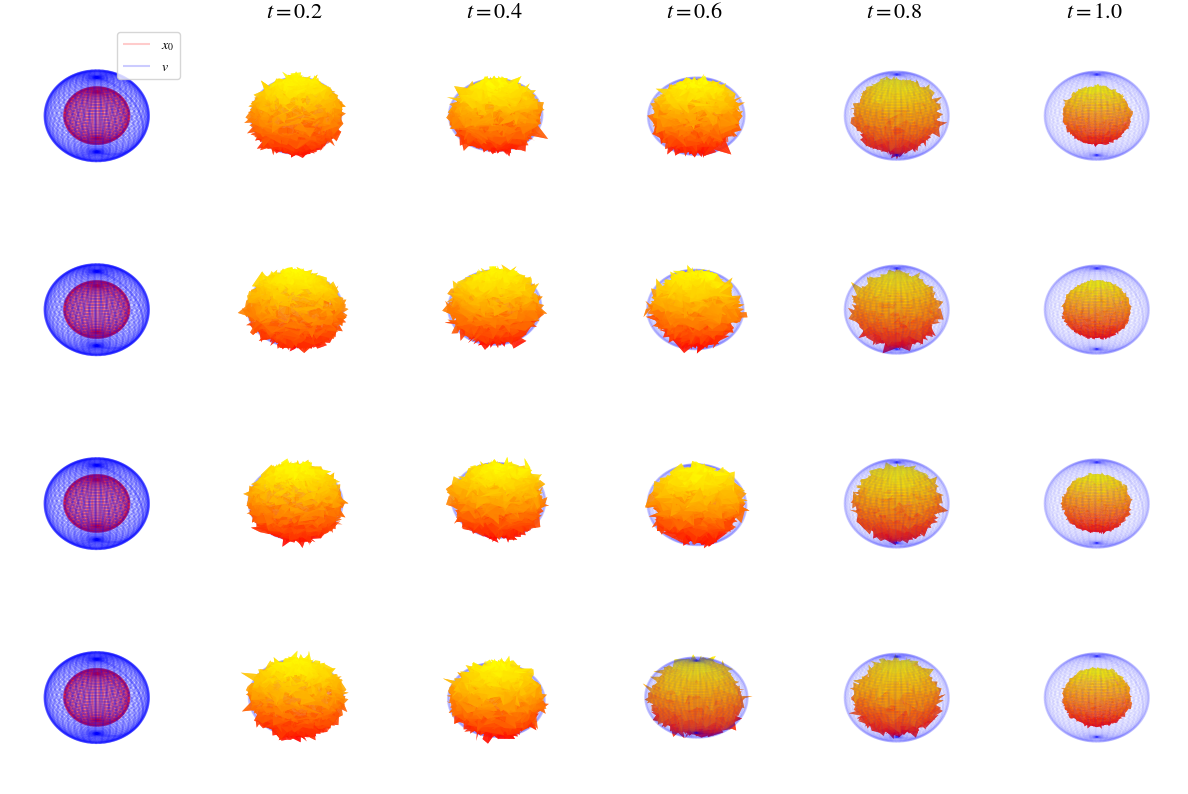

In [16]:
xs = reverse_path_true.xs
# xs_true = reverse_path_true.xs

with plt.rc_context(bundles.icml2022(column="full", nrows=4, ncols=1, usetex=False, family="sans-serif")):  

    cmap = mpl.colormaps["autumn"]
    fig, axs = plt.subplots(4, 6, subplot_kw={'projection': '3d'}, figsize=(12, 8))

    for i in range(4):
        axs[i, 0].plot_wireframe(x0[:, :, 0], x0[:, :, 1], x0[:, :, 2], alpha=0.2, color="red", label=r"$x_0$")
        axs[i, 0].plot_wireframe(v[:, :, 0], v[:, :, 1], v[:, :, 2], alpha=0.2, color="blue", label=r"$v$")
        axs[i, 0].grid(False)
        axs[i, 0].set_axis_off()

    # axs[1, 0].plot_wireframe(x0[:, :, 0], x0[:, :, 1], x0[:, :, 2], alpha=0.2, color="red", label=r"$x_0$")
    # axs[1, 0].plot_wireframe(v[:, :, 0], v[:, :, 1], v[:, :, 2], alpha=0.2, color="blue", label=r"$v$")
    # axs[1, 0].grid(False)
    # axs[1, 0].set_axis_off()

        for j in range(1, 6):
            xt = xs[i, j*20-1]
            axs[i, j].plot_wireframe(x0[:, :, 0], x0[:, :, 1], x0[:, :, 2], alpha=0.05, color="red", label=r"$x_0$")
            axs[i, j].plot_surface(xt[:, :, 0], xt[:, :, 1], xt[:, :, 2], alpha=0.7, cmap=cmap, label=r"$y_t$", antialiased=True, shade=True, rstride=1, cstride=1)
            axs[i, j].plot_wireframe(v[:, :, 0], v[:, :, 1], v[:, :, 2], alpha=0.05, color="blue", label=r"$v$")
            axs[i, j].grid(False)
            axs[i, j].set_axis_off()
            axs[i, j].dist = 8
            axs[i, j].elev = 20
            axs[i, j].azim = -60
            
            # xt_true = xs_true[0, i*20-1]
            # axs[1, i].plot_wireframe(x0[:, :, 0], x0[:, :, 1], x0[:, :, 2], alpha=0.05, color="red", label=r"$x_0$")
            # axs[1, i].plot_surface(xt_true[:, :, 0], xt_true[:, :, 1], xt_true[:, :, 2], alpha=0.7, cmap=cmap, label=r"$y_t$", antialiased=True, shade=True, rstride=1, cstride=1)
            # axs[1, i].plot_wireframe(v[:, :, 0], v[:, :, 1], v[:, :, 2], alpha=0.05, color="blue", label=r"$v$")
            # axs[1, i].grid(False)
            # axs[1, i].set_axis_off()
            # axs[1, i].set_title(fr"$t = {i*20/100:.1f}$")  # Moved title down by increasing pad value
            # axs[1, i].dist = 8
            # axs[1, i].elev = 20
            # axs[1, i].azim = -60
            
    for j in range(1, 6):
        axs[0, j].set_title(fr"$t = {j*20/100:.1f}$", fontsize=16)  # Moved title down by increasing pad value
        

    axs[0, 0].legend(fontsize=10)
    
    fig.savefig("ellipsoid_brownian_samples.pdf", bbox_inches="tight", dpi=150)